# Credit Risk Prediction: Finance + Data Analysis + Machine Learning
**Goal:** Predict whether a loan applicant is a *good* or *bad* credit risk using the German Credit dataset (1,000 real applicants).

**Steps:** 1) Load data 2) Explore and visualize 3) Build ML models 4) Compare results 5) Conclusions

## 1. Load the data

In [13]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame
df['bad'] = (df['class'] == 'bad').astype(int)   # 1 = bad credit risk, 0 = good
print(df.shape)
df.head()

(1000, 22)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class,bad
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,67,none,own,2,skilled,1,yes,yes,good,0
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,22,none,own,1,skilled,1,none,yes,bad,1
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,49,none,own,1,unskilled resident,2,none,yes,good,0
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,45,none,for free,1,skilled,2,none,yes,good,0
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,53,none,for free,2,skilled,2,none,yes,bad,1


## 2. Explore the data

In [14]:
print("Missing values:", df.isnull().sum().sum())
print(df['class'].value_counts())
df[['duration','credit_amount','age']].describe()

Missing values: 0
class
good    700
bad     300
Name: count, dtype: int64


,duration,credit_amount,age
count,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,35.546000
std,12.058814,2822.736876,11.375469
min,4.000000,250.000000,19.000000
25%,12.000000,1365.500000,27.000000
50%,18.000000,2319.500000,33.000000
75%,24.000000,3972.250000,42.000000
max,72.000000,18424.000000,75.000000


/tmp/ipykernel_938/2717332680.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('credit_history')['bad'].mean().sort_values().plot(kind='barh', ax=ax[0])


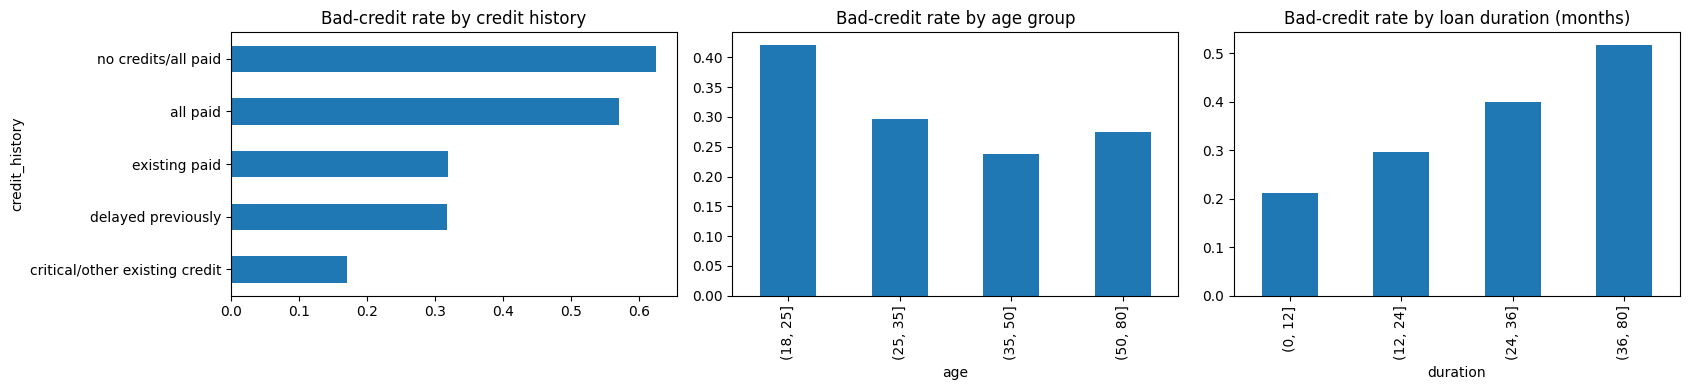

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4))

df.groupby('credit_history')['bad'].mean().sort_values().plot(kind='barh', ax=ax[0])
ax[0].set_title('Bad-credit rate by credit history')

df.groupby(pd.cut(df['age'], [18, 25, 35, 50, 80]), observed=True)['bad'].mean().plot(kind='bar', ax=ax[1])
ax[1].set_title('Bad-credit rate by age group')

df.groupby(pd.cut(df['duration'], [0, 12, 24, 36, 80]), observed=True)['bad'].mean().plot(kind='bar', ax=ax[2])
ax[2].set_title('Bad-credit rate by loan duration (months)')

plt.tight_layout(); plt.show()

**Observation:** The bad-credit rate rises clearly with loan duration, from about 21% for loans up to 12 months to about 52% for loans longer than 36 months. Younger applicants (18-25) had the highest bad-credit rate (about 42%), while applicants aged 35-50 had the lowest (about 24%). By credit history, applicants with "no credits/all paid" or "all paid" had the highest bad-credit rate (about 57-62%), and those with a critical or other existing credit had the lowest (about 17%). This last result is surprising and may be due to how this small dataset was collected.

## 3. Build the ML models

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

X = df.drop(columns=['class', 'bad'])
y = df['bad']

num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

# Scale numbers, convert text categories to 0/1 columns
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
}

fitted = {}
for name, model in models.items():
    pipe = Pipeline([('pre', pre), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fitted[name] = pipe
    print('=====', name, '=====')
    print('Accuracy:', round(accuracy_score(y_test, pred), 3))
    print(classification_report(y_test, pred, target_names=['good', 'bad']))

===== Logistic Regression =====
Accuracy: 0.75
              precision    recall  f1-score   support

        good       0.89      0.73      0.80       140
         bad       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200

===== Random Forest =====
Accuracy: 0.755
              precision    recall  f1-score   support

        good       0.77      0.92      0.84       140
         bad       0.67      0.37      0.47        60

    accuracy                           0.76       200
   macro avg       0.72      0.64      0.66       200
weighted avg       0.74      0.76      0.73       200



## 4. Confusion matrices and important features

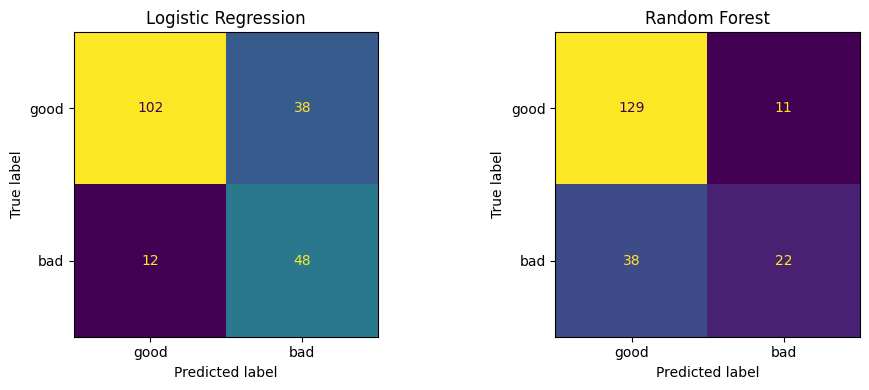

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (name, pipe) in zip(ax, fitted.items()):
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, display_labels=['good', 'bad'], ax=a, colorbar=False)
    a.set_title(name)
plt.tight_layout(); plt.show()

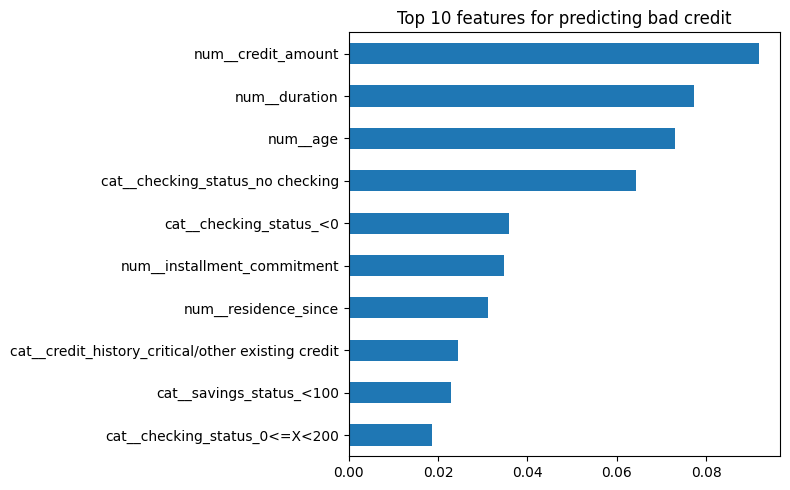

In [12]:
rf = fitted['Random Forest']
names = rf.named_steps['pre'].get_feature_names_out()
imp = pd.Series(rf.named_steps['model'].feature_importances_, index=names)
imp.sort_values().tail(10).plot(kind='barh', figsize=(8, 5), title='Top 10 features for predicting bad credit')
plt.tight_layout(); plt.show()

## 5. Conclusions

- In this project, I used the German Credit dataset (1,000 loan applicants) to predict whether an applicant is a good or bad credit risk.
- I trained two models: Logistic Regression and Random Forest. Logistic Regression got 75% accuracy and Random Forest got 75.5%, so their overall accuracy was almost the same.
- However, the models behave differently. On the 200 test applicants (60 truly bad), Logistic Regression correctly caught 48 bad-credit applicants (80%), while Random Forest caught only 22 (37%). For a bank, missing a risky borrower is costly, so Logistic Regression is more useful here even though its accuracy is slightly lower.
- The most important features for predicting bad credit were credit amount, loan duration and age, followed by having no checking account and the installment commitment.
- My charts showed that the bad-credit rate was higher for longer loans (over 36 months) and for younger applicants (18-25).
- Limitations: the dataset is small (1,000 rows) and not recent, so the model can make mistakes and should not be used for real loan decisions.
- Next steps: I want to try more models, tune their settings, and test on a larger dataset.